## Predicting House Prices with Linear Models

Notebook consists of:

1. Preprocessing the Data
2. EDA of the Data
3. Feature Engineering
4. Linear Model Training
5. XGBoost Benchmarking
6. Model Interpretation

In [1]:
# -------- initialise ----------
DATA_PATH = "data/house_dataset.csv"
RANDOM_SEED = 42

In [2]:
# -------- our internal helper imports --------------

from utils.feature_engineering import run_feature_engineering
from utils.data_preprocessing import build_preprocessor
from utils.evaluation_helpers import mape, mape_scorer, cv_mape

# -------- external imports --------------
import pandas as pd
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import xgboost as xgb

### Step 1: Preprocessing

In [9]:
# DATA LOADING
df = pd.read_csv(DATA_PATH)

print(f"Initial shape: {df.shape}")
display(df.head(3))

Initial shape: (9200, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.5,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.0,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA


In [11]:
# PRE-PROCESSING

# Ensure date column is in datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check for invalid dates
invalid_dates = df["date"].isnull().sum()
if invalid_dates > 0:
    print("Invalid dates found:", invalid_dates)
else:
    print("No invalid dates found.")

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print("Duplicate rows found:", duplicate_count)
else:
    print("No duplicate rows found.")

# Check for missing values
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print("\nMissing data found:")
    print(missing_data[missing_data > 0])
else:
    print("\nNo missing data found.")

No invalid dates found.
Duplicate rows found: 4598

No missing data found.


### Outlier Detection and Removal

Outliers can negatively affect regression models by disproportionately influencing model parameters and reducing predictive performance. To mitigate this issue, we detect and remove extreme values in the dataset using the **Interquartile Range (IQR) method**, which is a robust statistical technique commonly used in exploratory data analysis.

For each numeric feature:

- \(Q1\) represents the 25th percentile  
- \(Q3\) represents the 75th percentile  
- \(IQR = Q3 - Q1\)

An observation is considered an outlier if it falls outside the following bounds:

- Lower Bound = Q1 - 1.5*times IQR
- Upper Bound = Q3 + 1.5*times IQR

Any values outside this range are removed to reduce the influence of extreme observations while preserving the majority of the dataset.

This approach helps ensure that the subsequent regression models are trained on a dataset that better represents the typical distribution of housing features.

In [ ]:
# OUTLIER DETECTION & REMOVAL (IQR Method)

numeric_cols = df.select_dtypes(include=['number']).columns

rows_before = df.shape[0]

# Compute IQR bounds
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataset once using all bounds
df_filtered = df[~((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)]

rows_after = df_filtered.shape[0]

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Outliers removed:", rows_before - rows_after)

# Replace dataset
df = df_filtered

# Check updated dataset
print("Final dataset shape:", df.shape)

Rows before outlier removal: 6356
Rows after outlier removal: 6266
Outliers removed: 90
Final dataset shape: (6266, 18)


### Train/Test Split

To evaluate model performance fairly, the dataset is divided into **training** and **test** sets.

Two splitting strategies are considered:

1. **Random Split**  
   The dataset is randomly divided into training and testing subsets. This is the most common approach and assumes that observations are independently distributed.

2. **Time-Based Split**  
   Since the dataset contains a `date` variable representing housing transactions over time, we may also split the data chronologically.  
   In this case, earlier observations are used for training while later observations are used for testing, which better mimics real-world prediction scenarios.

To allow easy experimentation, we implement a **toggle** that allows switching between random and time-based splits.

In [ ]:
# 1. RANDOM TRAIN/TEST SPLIT

# Import train_test_split from sklearn to randomly divide the dataset
from sklearn.model_selection import train_test_split

# Define the target variable
target = "price"

# Separate the predictors (X) and the target variable (y)
# X contains all columns except the target
# y contains only the target column
X = df.drop(columns=[target])
y = df[target]

# Perform a random train/test split
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility of the split
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# Print the shapes of the resulting datasets
# This confirms that the split occurred correctly
print("Random Split:")
print("X_train shape:", X_train_random.shape)
print("X_test shape:", X_test_random.shape)
print("y_train shape:", y_train_random.shape)
print("y_test shape:", y_test_random.shape)

Random Split:
X_train shape: (5012, 17)
X_test shape: (1254, 17)
y_train shape: (5012,)
y_test shape: (1254,)


In [19]:
# 2. TIME-BASED TRAIN/TEST SPLIT

# Define the target variable
target = "price"

# Sort dataset chronologically by date before splitting
df = df.sort_values("date").reset_index(drop=True)

# Separate features (X) and target variable (y)
X = df.drop(columns=[target])
y = df[target]

# Define the split index using 80% of the dataset for training
split_index = int(len(df) * 0.8)

# Use earlier observations as the training set
X_train_time = X.iloc[:split_index]
y_train_time = y.iloc[:split_index]

# Use later observations as the test set
X_test_time = X.iloc[split_index:]
y_test_time = y.iloc[split_index:]

# Print dataset sizes
print("Time-based Split:")
print("X_train shape:", X_train_time.shape)
print("X_test shape:", X_test_time.shape)
print("y_train shape:", y_train_time.shape)
print("y_test shape:", y_test_time.shape)

# Verify chronological order
print("\nTrain date range:", X_train_time["date"].min(), "to", X_train_time["date"].max())
print("Test date range:", X_test_time["date"].min(), "to", X_test_time["date"].max())

Time-based Split:
X_train shape: (5012, 17)
X_test shape: (1254, 17)
y_train shape: (5012,)
y_test shape: (1254,)

Train date range: 2014-05-02 00:00:00 to 2014-06-26 00:00:00
Test date range: 2014-06-26 00:00:00 to 2014-07-10 00:00:00


The time-based split preserves chronological order at the transaction level, though observations from the same date may appear in both train and test sets.

### Step 2. EDA

Exploratory Data Analysis (EDA) is conducted to better understand the structure, distribution, and relationships within the dataset before building predictive models.

The goal of this step is to identify patterns, detect potential anomalies, and understand how different housing features relate to the target variable **price**. These insights help guide feature engineering and ensure that the assumptions of linear modelling techniques are reasonable.

In this analysis, we focus on the following aspects:

1. **Understanding feature types**  
   Identify which variables are numeric and suitable for correlation and regression analysis.

2. **Correlation analysis**  
   Examine the relationships between numeric variables using a correlation matrix. This helps identify features that may strongly influence house prices and detect potential multicollinearity among predictors.

3. **Distribution of key variables**  
   Inspect the distribution of important features such as price and living area to understand skewness and variability.

4. **Relationships between features and price**  
   Visualize how important housing characteristics (e.g., living space, number of bedrooms, number of bathrooms) relate to the target variable.

5. **Temporal patterns**  
   Since the dataset includes a transaction **date**, we also explore how prices evolve over time to detect potential trends or seasonal patterns.

These exploratory insights provide a foundation for selecting and transforming features in the next stage of the modelling pipeline.

Numeric columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']


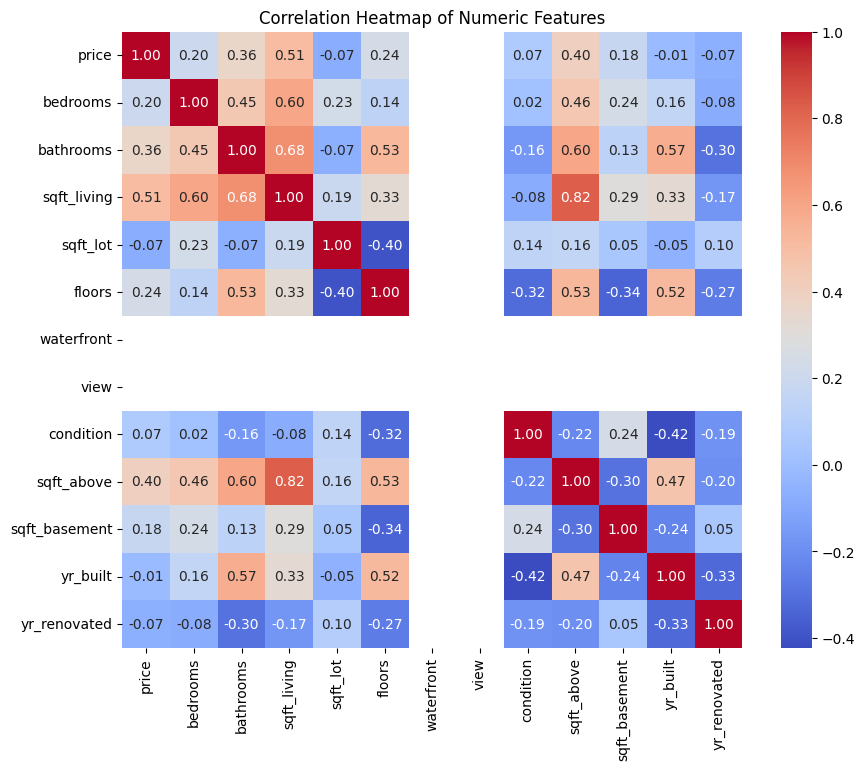

In [20]:
# get list of numeric columns in data
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# plot correlation heatmap of numeric features to target 'price'
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
## TODO: ideas for more EDA, 
## get list of categorical columns and check what their median price is
## similarly plot price against date column - check for monthly/yearly/seasonality trends

### Step 3: Feature Engineering

In [ ]:
# TODO: create the final feature set we want to train models on

# X_train_fe, y_train_fe, X_test_fe, y_test_fe = run_feature_engineering(df)

BINARY_COLS = []
ORDINAL_COLS = []
CONTNOUS_COLS = []

### Step 4: Linear Model Training

In [ ]:
# ── Model factory ─────────────────────────────────────────────
# Add / tweak models here, these are the basic ones - if we want to use different features/different train test splits we can add them here

preprocessor = build_preprocessor(X_train_fe, BINARY_COLS, ORDINAL_COLS, CONTNOUS_COLS) 

ALPHAS = np.logspace(-3, 4, 50)

MODELS = {
    "OLS"       : Pipeline([("pre", preprocessor), ("model", LinearRegression())]),
    "Ridge"     : Pipeline([("pre", preprocessor), ("model", RidgeCV(alphas=ALPHAS, cv=CV_FOLDS))]),
    "Lasso"     : Pipeline([("pre", preprocessor), ("model", LassoCV(alphas=ALPHAS, cv=CV_FOLDS, max_iter=5000))]),
    "ElasticNet": Pipeline([("pre", preprocessor), ("model", ElasticNetCV(cv=CV_FOLDS, max_iter=5000))]),
}

print("Models defined:", list(MODELS.keys()))

In [ ]:
# TODO: do cross-validated MAPE here for each model and print results

In [ ]:
# TODO: then pick WINNER model from above results and train on ALL training data

### Step 5: XGBoost Benchmark

In [ ]:
# TODO: train xgboost model on all training data & get preds on test, compare with WINNER preds above

### Step 6: Model Intepretation

In [ ]:
# TODO: print feature_names & coefficients
# TODO: bar chart of top features
# TODO: paragraph to explain